# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [24]:
pip install scikit-learn pandas numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [25]:
!pip install nltk

Failed to canonicalize script path


In [26]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Carga del corpus ─────────────────────────────────────────────
CORPUS_PATH = "wikipedia_text_corpus.csv"
df = pd.read_csv(CORPUS_PATH)

print(df.head())

   Unnamed: 0                                               text
0           1  Anovo\n\nAnovo (formerly A Novo) is a computer...
1           2  Battery indicator\n\nA battery indicator (also...
2           3  Bob Pease\n\nRobert Allen Pease (August 22, 19...
3           4  CAVNET\n\nCAVNET was a secure military forum w...
4           5  CLidar\n\nThe CLidar is a scientific instrumen...


In [28]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

# Descarga de recursos necesarios
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocesar_texto(texto):
    texto = texto.lower()
    tokens = word_tokenize(texto)
    tokens_limpios = [
        word for word in tokens 
        if word.isalpha() and word not in stop_words
    ]
    return " ".join(tokens_limpios)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\enriq\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\enriq\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
df['text_clean'] = df['text'].apply(preprocesar_texto)

print(df[['text', 'text_clean']].head())

                                                text  \
0  Anovo\n\nAnovo (formerly A Novo) is a computer...   
1  Battery indicator\n\nA battery indicator (also...   
2  Bob Pease\n\nRobert Allen Pease (August 22, 19...   
3  CAVNET\n\nCAVNET was a secure military forum w...   
4  CLidar\n\nThe CLidar is a scientific instrumen...   

                                          text_clean  
0  anovo anovo formerly novo computer services co...  
1  battery indicator battery indicator also known...  
2  bob pease robert allen pease august june analo...  
3  cavnet cavnet secure military forum became ope...  
4  clidar clidar scientific instrument used measu...  


In [30]:
documents = df['text_clean'].astype(str).tolist()

print(f"Documentos cargados: {len(documents)}")
print(f"Ejemplo: {documents[0][:100]}")

Documentos cargados: 10859
Ejemplo: anovo anovo formerly novo computer services company based beauvais france founded went public curren


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

In [32]:
# ── TF-IDF con sklearn ───────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["text_clean"])

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print(f"Dimensiones de la matriz TF-IDF: {df_tfidf.shape}")
df_tfidf.head()

Dimensiones de la matriz TF-IDF: (10859, 1000)


,ability,able,access,according,account,achieve,achieved,acid,acquired,act,...,worked,workers,working,works,world,worldwide,written,year,years,york
0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.185576,0.0
1,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.13952,0.0,0.056875,0.0,0.0,0.0,0.059424,0.0
3,0.0,0.000000,0.199206,0.0,0.0,0.0,0.0,0.0,0.225987,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.061266,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

def buscar_tfidf(query, vectorizer, tfidf_matrix, df, top_k=5):
    query_vector = vectorizer.transform([query])
    
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    ranking = pd.DataFrame({
        "articulo_idx": df.index,
        "score": scores
    })
    
    return (ranking
            .sort_values(by="score", ascending=False)
            .head(top_k)
            .reset_index(drop=True))

In [34]:
queries = [
    "how computer services work",
    "battery life and charging indicators",
    "analog circuit design and engineering",
    "military communication forums",
    "scientific instruments for measurement",
    "software development projects",
    "history of computing",
    "electronic component failure",
    "renewable energy sources",
    "aerospace engineering tools"
]

# Diccionario para guardar resultados
resultados_totales = {}

print("--- RESULTADOS DE RECUPERACIÓN TF-IDF ---")
for q in queries:
    res = buscar_tfidf(q, tfidf_vectorizer, tfidf_matrix, df)
    resultados_totales[q] = res
    print(f"\nQuery: '{q}'")
    print(res)

--- RESULTADOS DE RECUPERACIÓN TF-IDF ---

Query: 'how computer services work'
   articulo_idx     score
0          2923  0.591410
1           260  0.540295
2          2026  0.513373
3           120  0.505298
4          5814  0.458923

Query: 'battery life and charging indicators'
   articulo_idx     score
0             1  0.727823
1          1391  0.684060
2          9888  0.596745
3          7039  0.546486
4          6464  0.535953

Query: 'analog circuit design and engineering'
   articulo_idx     score
0          6955  0.569967
1           641  0.534381
2          2544  0.534078
3          7247  0.518753
4          9317  0.515243

Query: 'military communication forums'
   articulo_idx     score
0          3980  0.604536
1          2105  0.596098
2           790  0.561889
3          6158  0.546520
4          1889  0.534763

Query: 'scientific instruments for measurement'
   articulo_idx     score
0          7022  0.562716
1          5689  0.562716
2         10040  0.562716
3        

## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [35]:
# ── Tokenización del corpus ──────────────────────────────────────
from nltk.tokenize import word_tokenize
import string

nltk.download("punkt_tab", quiet=True)

def tokenize(text: str) -> list[str]:
    """Tokeniza y limpia el texto eliminando puntuación y lowercase."""
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha()]

tokenized_corpus = [tokenize(text) for text in df["text_clean"]]

print(f"Documentos tokenizados: {len(tokenized_corpus)}")
print(f"Ejemplo (primeros 10 tokens): {tokenized_corpus[0][:10]}")

Documentos tokenizados: 10859
Ejemplo (primeros 10 tokens): ['anovo', 'anovo', 'formerly', 'novo', 'computer', 'services', 'company', 'based', 'beauvais', 'france']


In [36]:
# ── Longitud de documentos y promedio ───────────────────────────
doc_lengths = np.array([len(tokens) for tokens in tokenized_corpus])
avg_doc_length = doc_lengths.mean()

print(f"Longitud promedio de documentos (avgdl): {avg_doc_length:.2f}")
print(f"Longitud mínima: {doc_lengths.min()} | Máxima: {doc_lengths.max()}")

Longitud promedio de documentos (avgdl): 429.87
Longitud mínima: 1 | Máxima: 19215


In [37]:
# ── Frecuencia de término (TF) por documento ─────────────────────
from collections import Counter

def compute_tf(tokens: list[str]) -> dict[str, int]:
    """Calcula la frecuencia de cada término en un documento."""
    return Counter(tokens)

tf_corpus = [compute_tf(tokens) for tokens in tokenized_corpus]

# Ejemplo
print(f"TF del primer documento (top 5):")
print(sorted(tf_corpus[0].items(), key=lambda x: x[1], reverse=True)[:5])

TF del primer documento (top 5):
[('anovo', 2), ('company', 2), ('formerly', 1), ('novo', 1), ('computer', 1)]


In [38]:
# ── Document Frequency (DF) e IDF estilo BM25 ───────────────────
from collections import defaultdict

N = len(tokenized_corpus)  # Total de documentos

# DF: número de documentos que contienen cada término
df_bm25 = defaultdict(int)
for tf_doc in tf_corpus:
    for term in tf_doc:
        df_bm25[term] += 1

def compute_idf_bm25(term, N, df_dict):
    """Calcula el IDF específico para BM25 con suavizado."""
    df_t = df_dict.get(term, 0)
    return np.log((N - df_t + 0.5) / (df_t + 0.5) + 1)

In [39]:
def bm25_score(query_tokens, tf_doc, doc_len, avg_dl, N, df_dict, k1=1.5, b=0.75):
    """Calcula el score BM25 total de un documento para una consulta."""
    score = 0.0
    for term in query_tokens:
        if term not in tf_doc:
            continue
        
        tf_td = tf_doc[term]
        # Aquí es donde se pasaban 3 argumentos al IDF
        idf = compute_idf_bm25(term, N, df_dict)
        
        # Fórmula de saturación y normalización
        numerator = tf_td * (k1 + 1)
        denominator = tf_td + k1 * (1 - b + b * (doc_len / avg_dl))
        
        score += idf * (numerator / denominator)
    return score

In [40]:
N = len(tokenized_corpus)
avg_doc_length = np.mean([len(doc) for doc in tokenized_corpus])

def buscar_bm25(query, tf_corpus, doc_lengths, avg_dl, N, df_dict, df_original, top_k=5):
    query_tokens = tokenize(query)
    
    # Calculamos scores para cada documento
    scores = [
        bm25_score(query_tokens, tf_doc, doc_len, avg_dl, N, df_dict)
        for tf_doc, doc_len in zip(tf_corpus, doc_lengths)
    ]
    
    ranking = pd.DataFrame({
        "articulo_idx": df.index,
        "score_bm25": scores
    })
    
    return ranking.sort_values(by="score_bm25", ascending=False).head(top_k).reset_index(drop=True)

In [41]:
for q in queries[:10]:
    print(f"\nResultados BM25 para: '{q}'")
    print(buscar_bm25(q, tf_corpus, doc_lengths, avg_doc_length, N, df_bm25, df))


Resultados BM25 para: 'how computer services work'
   articulo_idx  score_bm25
0          2923   11.078711
1          4613   10.512250
2          8910    9.542445
3          7156    9.400529
4         10579    9.350660

Resultados BM25 para: 'battery life and charging indicators'
   articulo_idx  score_bm25
0          9888   17.948681
1          5040   17.672546
2          8585   17.158380
3          6358   16.798168
4          4480   16.151631

Resultados BM25 para: 'analog circuit design and engineering'
   articulo_idx  score_bm25
0          3643   18.027499
1             2   17.159515
2          3127   17.039427
3          1670   16.821186
4          2627   15.735042

Resultados BM25 para: 'military communication forums'
   articulo_idx  score_bm25
0          7065   11.696775
1          2105   11.502550
2          6999   11.304280
3          8367   11.184150
4          8112   10.861596

Resultados BM25 para: 'scientific instruments for measurement'
   articulo_idx  score_bm25
0   

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

In [42]:
def comparar_modelos(query, vectorizer, tfidf_matrix, tf_corpus, doc_lengths, avg_dl, N, df_bm25, df, top_k=5):
    # Obtener Top K de TF-IDF
    res_tfidf = buscar_tfidf(query, vectorizer, tfidf_matrix, df, top_k)
    
    # Obtener Top K de BM25
    res_bm25 = buscar_bm25(query, tf_corpus, doc_lengths, avg_dl, N, df_bm25, df, top_k)
    
    # Unir para comparar
    df_comp = pd.DataFrame({
        "Rank": range(1, top_k + 1),
        "TF-IDF": res_tfidf["articulo_idx"].values,
        "Score TF-IDF": res_tfidf["score"].values,
        "BM25": res_bm25["articulo_idx"].values,
        "Score BM25": res_bm25["score_bm25"].values
    })
    return df_comp

# Prueba con una de tus queries
ejemplo_comp = comparar_modelos(queries[1], tfidf_vectorizer, tfidf_matrix, 
                                tf_corpus, doc_lengths, avg_doc_length, N, df_bm25, df)
print(f"Comparación para: '{queries[1]}'")
print(ejemplo_comp)

Comparación para: 'battery life and charging indicators'
   Rank  TF-IDF  Score TF-IDF  BM25  Score BM25
0     1       1      0.727823  9888   17.948681
1     2    1391      0.684060  5040   17.672546
2     3    9888      0.596745  8585   17.158380
3     4    7039      0.546486  6358   16.798168
4     5    6464      0.535953  4480   16.151631


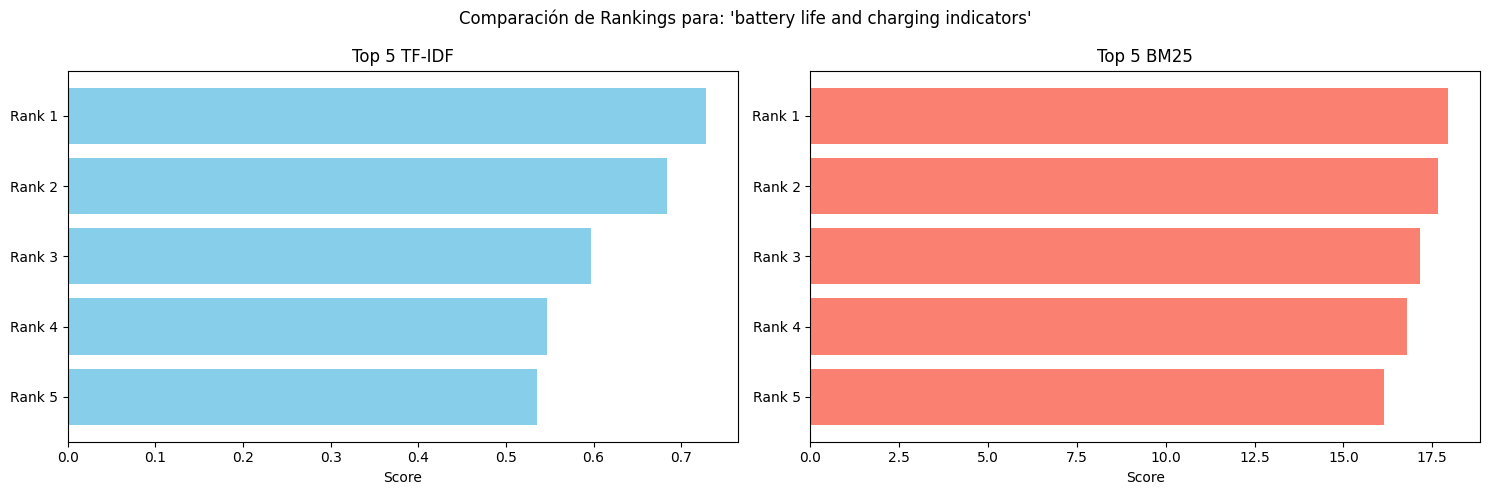

In [44]:
import matplotlib.pyplot as plt
%matplotlib inline

def graficar_comparacion(df_comp, query):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    ranks = [f"Rank {i}" for i in df_comp["Rank"]]
    
    # Gráfico TF-IDF
    ax[0].barh(ranks, df_comp["Score TF-IDF"], color='skyblue')
    ax[0].set_title("Top 5 TF-IDF")
    ax[0].set_xlabel("Score")
    ax[0].invert_yaxis()
    
    # Gráfico BM25
    ax[1].barh(ranks, df_comp["Score BM25"], color='salmon')
    ax[1].set_title("Top 5 BM25")
    ax[1].set_xlabel("Score")
    ax[1].invert_yaxis()
    
    plt.suptitle(f"Comparación de Rankings para: '{query}'")
    plt.tight_layout()
    plt.show()

# Ejecutar para la primera consulta
graficar_comparacion(ejemplo_comp, queries[1])